--- Initial Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         60 non-null     object
 1   Price         60 non-null     object
 2   Rating        60 non-null     object
 3   Availability  60 non-null     object
dtypes: object(4)
memory usage: 2.0+ KB
None

--- Statistical Summary of Prices ---
count    60.000000
mean     35.002667
std      14.553082
min      12.840000
25%      22.040000
50%      33.485000
75%      50.142500
max      57.310000
Name: Price, dtype: float64

Visual 1 saved: price_distribution.png


C:\Users\sony\AppData\Local\Temp\ipykernel_17508\3677141118.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', order=['One', 'Two', 'Three', 'Four', 'Five'], palette='viridis')


Visual 2 saved: ratings_count.png

Insight: The most expensive book is 'Slow States of Collapse: Poems' at £57.31


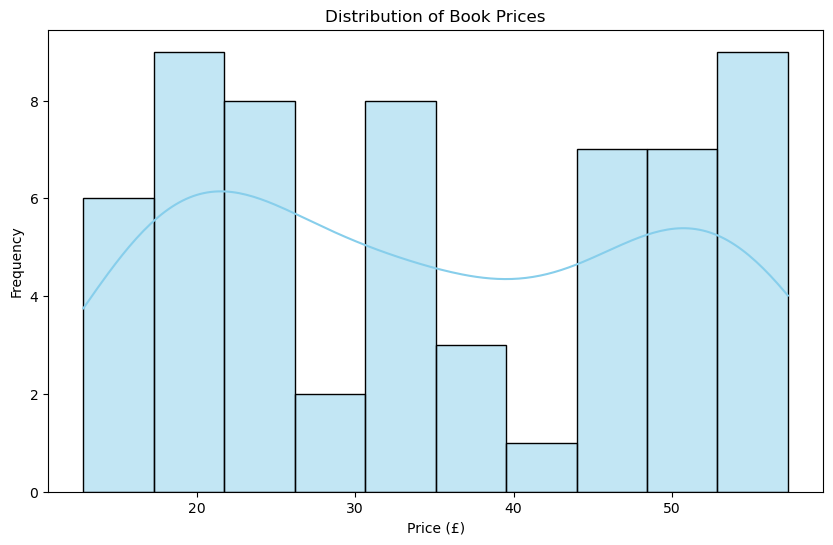

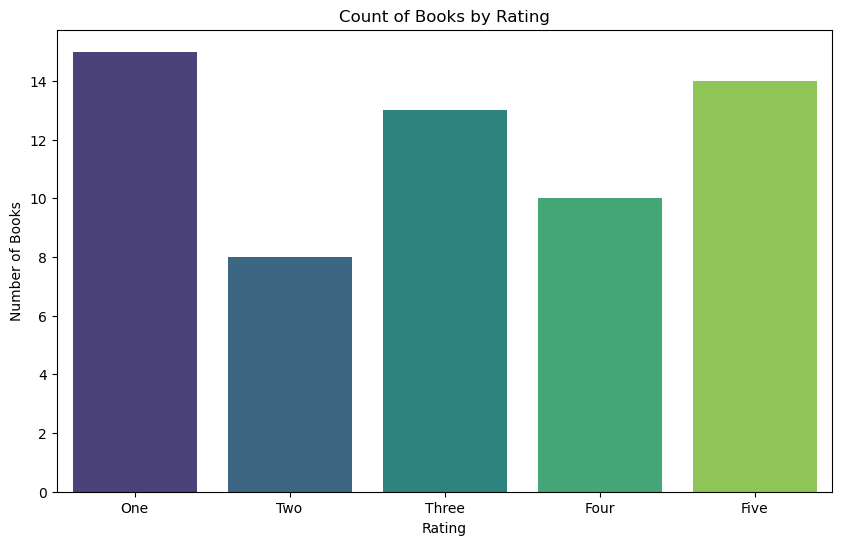

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def perform_eda():
    # 1. Load the dataset we created in Task 1
    try:
        df = pd.read_csv("CodeAlpha_Books_Dataset.csv")
    except FileNotFoundError:
        print("Error: Dataset not found. Please run Task 1 first.")
        return

    print("--- Initial Data Overview ---")
    print(df.info())
    
    # 2. Data Cleaning: Convert Price from string (£25.00) to float (25.00)
    df['Price'] = df['Price'].str.replace('£', '').astype(float)
    
    # 3. Statistical Summary
    print("\n--- Statistical Summary of Prices ---")
    print(df['Price'].describe())

    # 4. Visualization - Price Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Price'], bins=10, kde=True, color='skyblue')
    plt.title('Distribution of Book Prices')
    plt.xlabel('Price (£)')
    plt.ylabel('Frequency')
    plt.savefig('price_distribution.png')
    print("\nVisual 1 saved: price_distribution.png")

    # 5. Visualization - Ratings Count
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='Rating', order=['One', 'Two', 'Three', 'Four', 'Five'], palette='viridis')
    plt.title('Count of Books by Rating')
    plt.xlabel('Rating')
    plt.ylabel('Number of Books')
    plt.savefig('ratings_count.png')
    print("Visual 2 saved: ratings_count.png")

    # 6. Identifying Insights
    expensive_book = df.loc[df['Price'].idxmax()]
    print(f"\nInsight: The most expensive book is '{expensive_book['Title']}' at £{expensive_book['Price']}")

if __name__ == "__main__":
    perform_eda()